<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Clase 15: Gráficos avanzados y mapas**

En esta clase veremos como realizar diferentes gráficos para su posterior interpretación y análisis



###**Librería**


**Librerías para graficar**

[**Matplotlib**](https://matplotlib.org/)

Cualquier gráfico. Sobre todo permite operar los atributos (colores, marcadores, comentarios). Se suele utilizar en combinación con las otras librerías para los atributos

In [1]:
import matplotlib.pyplot as plt

[**Seaborn**](https://seaborn.pydata.org/)

Principalmente gráficos estadísticos

In [2]:
import seaborn as sns

[**PLOTY**](https://plotly.com/python/)

Gráficos iteractivos

In [3]:
import plotly.express as px

In [4]:
import plotly.graph_objects as go

**Otras librerías**

In [5]:
from datetime import datetime

In [6]:
import matplotlib.dates as mdates

In [7]:
import pandas as pd

In [8]:
import numpy as np

In [9]:
import kagglehub

In [10]:
import warnings
warnings.filterwarnings('ignore') #oculatar texto warning

###**Gráficos Indicadores**

Obtención de datos mensuales de la cotización de acciones de Google

In [11]:
import pandas as pd
import yfinance as yf

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2023-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_GOOG=Datos_GOOG.assign(SYMBOL_YAHOO_FINANCE='T_GOOG', SECTOR='TECNOLOGIA')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_GOOG

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,SYMBOL_YAHOO_FINANCE,SECTOR
0,2023-06-01,118.802361,128.072316,115.229359,121.898966,656851900,T_GOOG,TECNOLOGIA
1,2023-07-01,131.724716,132.737071,114.484973,118.345801,708341900,T_GOOG,TECNOLOGIA


In [14]:
#ajustando el formato

fig = go.Figure(go.Indicator(
     domain = {'x': [0, 1], 'y': [0, 1]},
    value = round(Datos_GOOG['Close'][1],1),
    mode = "gauge+number+delta",
    title = {'text': "Close Price Google Julio 2023"},
    delta = {'reference': round(Datos_GOOG['Close'][0],1)},
    gauge = {'axis': {'range': [None, 150]},
             'steps' : [
                 {'range': [0, 50], 'color': "lightgray"},
                 {'range': [50, 100], 'color': "darkgray"},
                 {'range': [100, 150], 'color': "gray"}],
             'threshold' : {'line': {'color': "red", 'width': 4}, 'thickness': 0.75, 'value': 150}}))

fig.show()

In [15]:
# otra forma de visualizar el mismo dato
fig = go.Figure()

fig.add_trace(go.Indicator(
    value = round(Datos_GOOG['Close'][1],1),
    delta = {'reference': round(Datos_GOOG['Close'][0],1)},
    gauge = {'shape': "bullet",
        'axis': {'visible': False}},
    domain = {'row': 0, 'column': 0}))

fig.update_layout(
    grid = {'rows': 1, 'columns': 1, 'pattern': "independent"},
    template = {'data' : {'indicator': [{
        'title': {'text': "Close Price Google Julio 2023"},
        'mode' : "number+delta+gauge",
        'delta' : {'reference': 90}}]
                         }})


fig.update_layout(
    margin=dict(l=350, r=100, t=100, b=100)
)

In [16]:
#si solo se quiere la variación

fig = go.Figure()

fig.add_trace(go.Indicator(value = round(Datos_GOOG['Close'][1],1),
    delta = {'reference': round(Datos_GOOG['Close'][0],1)},
    mode = "delta",
    domain = {'row': 0, 'column': 0}))

fig.update_layout(
    grid = {'rows': 1, 'columns': 1, 'pattern': "independent"},
    template = {'data' : {'indicator': [{
        'title': {'text': "Variación Close Price Google Julio 2023"},
        'mode' : "number+delta+gauge",
        'delta' : {'reference': 90}}]
                         }})


fig.update_layout(
    margin=dict(l=350, r=100, t=100, b=100)
)

### **Gráfico Bullet**

Recuerde primero importar al colab sus credenciales (.json)

Obtención de los datos

https://www.kaggle.com/datasets/paytonfisher/sp-500-companies-with-financial-information

In [17]:
path = kagglehub.dataset_download("paytonfisher/sp-500-companies-with-financial-information")

print("Path to dataset files:", path)


100%|██████████| 29.5k/29.5k [00:00<00:00, 23.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/paytonfisher/sp-500-companies-with-financial-information/versions/1


In [18]:

DATA=pd.read_csv("/root/.cache/kagglehub/datasets/paytonfisher/sp-500-companies-with-financial-information/versions/1/financials.csv")
DATA.head()

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,1.387211e+11,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,1.078342e+10,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,1.021210e+11,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,1.813863e+11,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,9.876586e+10,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [19]:
#medidas agregadas por Setcor
DATA_Sector=DATA.groupby(['Sector']).Price.agg(['count','mean', 'median']).reset_index()
DATA_Sector

,Sector,count,mean,median
0,Consumer Discretionary,84,124.034524,65.140
1,Consumer Staples,34,79.764118,69.750
2,Energy,32,57.887500,50.325
3,Financials,68,89.056029,71.105
4,Health Care,61,132.515738,96.420
5,Industrials,67,116.887612,87.600
6,Information Technology,70,119.242857,84.770
7,Materials,25,102.386800,105.180
8,Real Estate,33,88.712727,58.360
9,Telecommunication Services,3,33.603333,35.570


In [20]:
#se renombra una columna
DATA_Sector.rename(columns={'count': 'CANTIDAD'}, inplace=True)

In [21]:
DATA_Sector.head()

,Sector,CANTIDAD,mean,median
0,Consumer Discretionary,84,124.034524,65.140
1,Consumer Staples,34,79.764118,69.750
2,Energy,32,57.887500,50.325
3,Financials,68,89.056029,71.105
4,Health Care,61,132.515738,96.420


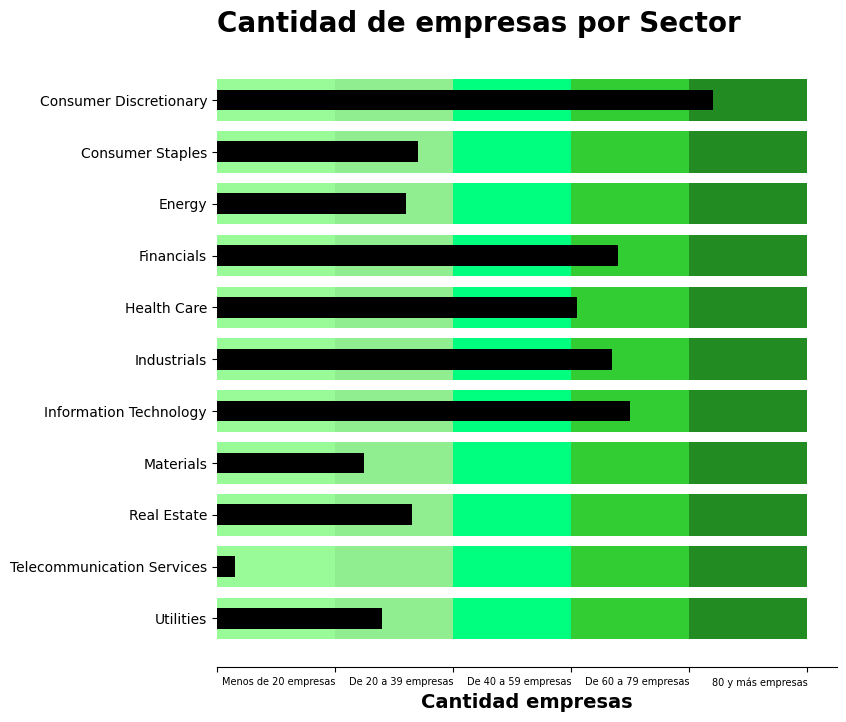

In [22]:
fig, ax = plt.subplots(figsize=(8,8))

colors = ["palegreen","lightgreen", "springgreen", "limegreen", "forestgreen"]

x = np.arange(len(DATA_Sector))
plt.barh(y=[0,0,0,0,0], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[1,1,1,1,1], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[2,2,2,2,2], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[3,3,3,3,3], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[4,4,4,4,4], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[5,5,5,5,5], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[6,6,6,6,6], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[7,7,7,7,7], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[8,8,8,8,8], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[9,9,9,9,9], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(y=[10,10,10,10,10], width=[20,20,20,20,20], left=[0,20,40,60,80], color=colors)
plt.barh(x, DATA_Sector["CANTIDAD"], height=0.4, align='center', color="black")

ax.set_yticklabels(DATA_Sector["Sector"])
ax.set_yticks(x)
ax.invert_yaxis()

ax.set_xticklabels(["", "Menos de 20 empresas", "De 20 a 39 empresas", "De 40 a 59 empresas", "De 60 a 79 empresas", "80 y más empresas"], ha='right', fontsize=7)

ax.spines[[ "top", "left", "right"]].set_visible(False)

plt.grid(False)

plt.xlabel("Cantidad empresas", fontsize=14, fontweight="bold")
plt.title("Cantidad de empresas por Sector", loc="left", pad=14, fontsize=20, fontweight="bold")

plt.show()


Bullet para un caso según estadísticas

In [23]:
#cálculo de cuartiles
def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)

def q90(x):
    return x.quantile(0.9)

DATA_Sector_2=DATA.groupby(['Sector']).Price.agg( ['min','mean', q25, 'median', q75, q90]).reset_index()

In [24]:
DATA_Sector_2.head()

,Sector,min,mean,q25,median,q75,q90
0,Consumer Discretionary,10.43,124.034524,39.7525,65.140,101.4075,177.638
1,Consumer Staples,19.96,79.764118,49.0325,69.750,101.1175,124.943
2,Energy,2.82,57.887500,28.2950,50.325,78.7450,100.955
3,Financials,13.38,89.056029,48.3275,71.105,104.5050,159.121
4,Health Care,25.20,132.515738,71.5100,96.420,173.1200,223.170


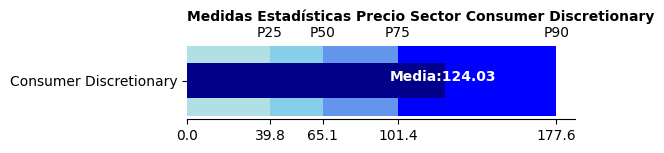

In [25]:
fig, ax = plt.subplots(figsize=(5,1))

colors = ["powderblue", "skyblue", "cornflowerblue", "blue"]

plt.barh(y=[0,0,0,0], width=[DATA_Sector_2['q25'][0], DATA_Sector_2['median'][0]-DATA_Sector_2['q25'][0],
                               DATA_Sector_2['q75'][0]-DATA_Sector_2['median'][0],DATA_Sector_2['q90'][0]-DATA_Sector_2['q75'][0]],
                        left=[0,DATA_Sector_2['q25'][0], DATA_Sector_2['median'][0],
                               DATA_Sector_2['q75'][0]], color=colors)
plt.barh(DATA_Sector_2["Sector"][0], DATA_Sector_2["mean"][0], height=0.4, align='center', color="darkblue")

plt.xticks([0,DATA_Sector_2['q25'][0], DATA_Sector_2["median"][0],DATA_Sector_2["q75"][0],DATA_Sector_2['q90'][0]])

ax.spines[[ "top", "left", "right"]].set_visible(False)

plt.title("Medidas Estadísticas Precio Sector Consumer Discretionary", loc="left", pad=15, fontsize=10, fontweight="bold")

ax.text(x=39.8, y=0.5, s='P25', ha='center',fontsize=10)
ax.text(x=65.1, y=0.5, s='P50', ha='center',fontsize=10)
ax.text(x=101.4, y=0.5, s='P75', ha='center',fontsize=10)
ax.text(x=177.6, y=0.5, s='P90', ha='center',fontsize=10)
ax.text(x=123, y=0, s='Media:124.03', ha='center',fontsize=10, color='white', fontweight="bold")

plt.show()

**Interacción**

In [26]:
DATA_Sector

,Sector,CANTIDAD,mean,median
0,Consumer Discretionary,84,124.034524,65.140
1,Consumer Staples,34,79.764118,69.750
2,Energy,32,57.887500,50.325
3,Financials,68,89.056029,71.105
4,Health Care,61,132.515738,96.420
5,Industrials,67,116.887612,87.600
6,Information Technology,70,119.242857,84.770
7,Materials,25,102.386800,105.180
8,Real Estate,33,88.712727,58.360
9,Telecommunication Services,3,33.603333,35.570


In [27]:
#requiere los datos en formato json
data={}
data['Sector']=DATA_Sector['Sector'].tolist()
data['Cantidad']=[[i,i] for i in DATA_Sector['CANTIDAD'].tolist()]
data['Ranges']=[[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100],[20,40,60,80,100]]

In [28]:
data

{'Sector': ['Consumer Discretionary',
  'Consumer Staples',
  'Energy',
  'Financials',
  'Health Care',
  'Industrials',
  'Information Technology',
  'Materials',
  'Real Estate',
  'Telecommunication Services',
  'Utilities'],
 'Cantidad': [[84, 84],
  [34, 34],
  [32, 32],
  [68, 68],
  [61, 61],
  [67, 67],
  [70, 70],
  [25, 25],
  [33, 33],
  [3, 3],
  [28, 28]],
 'Ranges': [[20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100],
  [20, 40, 60, 80, 100]]}

In [29]:
#contrucción del dataframe con datos en columnas como listas
pd.DataFrame(data)

,Sector,Cantidad,Ranges
0,Consumer Discretionary,"[84, 84]","[20, 40, 60, 80, 100]"
1,Consumer Staples,"[34, 34]","[20, 40, 60, 80, 100]"
2,Energy,"[32, 32]","[20, 40, 60, 80, 100]"
3,Financials,"[68, 68]","[20, 40, 60, 80, 100]"
4,Health Care,"[61, 61]","[20, 40, 60, 80, 100]"
5,Industrials,"[67, 67]","[20, 40, 60, 80, 100]"
6,Information Technology,"[70, 70]","[20, 40, 60, 80, 100]"
7,Materials,"[25, 25]","[20, 40, 60, 80, 100]"
8,Real Estate,"[33, 33]","[20, 40, 60, 80, 100]"
9,Telecommunication Services,"[3, 3]","[20, 40, 60, 80, 100]"


In [30]:
pd.DataFrame(data).dtypes

,0
Sector,object
Cantidad,object
Ranges,object


In [31]:
import plotly.figure_factory as ff

measure_colors=['rgb(63,102,153)', 'rgb(120,194,195)']
range_colors=['rgb(245,225,218)', 'rgb(241,241,241)']

fig = ff.create_bullet(pd.DataFrame(data), markers='', measures='Cantidad',ranges='Ranges', titles='Sector',
                        range_colors=range_colors, measure_colors=measure_colors)

fig.update_layout(autosize=False,width=1000,height=1000)

fig.update_layout(margin=dict(l=200, r=100, t=100, b=100))

fig.show()

### **Gráfico Cascada**

In [32]:
#obtención de datos
import yfinance as yf
VISA = pd.DataFrame(yf.download('V', start='2023-07-21', end='2023-08-01')).reset_index()
VISA.columns=VISA.columns.droplevel(1)
VISA

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2023-07-21,234.818207,235.897837,234.307835,235.299136,5427400
1,2023-07-24,236.280624,236.810615,233.777857,235.240247,6010000
2,2023-07-25,234.268555,236.339470,234.140958,235.573920,4997500
3,2023-07-26,232.708023,234.425606,223.462504,227.133230,7551400
4,2023-07-27,230.097321,234.239152,228.644740,233.022116,8160100
5,2023-07-28,231.383041,231.510638,229.380836,230.234716,6794800
6,2023-07-31,233.326370,234.003591,231.628420,231.628420,4799600


In [33]:
VISA_1=VISA[['Date', 'Open', 'Close']]
VISA_1

Price,Date,Open,Close
0,2023-07-21,235.299136,234.818207
1,2023-07-24,235.240247,236.280624
2,2023-07-25,235.573920,234.268555
3,2023-07-26,227.133230,232.708023
4,2023-07-27,233.022116,230.097321
5,2023-07-28,230.234716,231.383041
6,2023-07-31,231.628420,233.326370


In [34]:
VISA_1.dtypes

,0
Price,
Date,datetime64[ns]
Open,float64
Close,float64


In [35]:
#cálculo de variación absoluta y porcentual
VISA_1['Var_Diaria']=round(VISA['Close']-VISA['Open'],1)
VISA_1['Var%_Diaria']=round(((VISA['Close']-VISA['Open'])/VISA['Open'])*100, 1)
VISA_1

Price,Date,Open,Close,Var_Diaria,Var%_Diaria
0,2023-07-21,235.299136,234.818207,-0.5,-0.2
1,2023-07-24,235.240247,236.280624,1.0,0.4
2,2023-07-25,235.573920,234.268555,-1.3,-0.6
3,2023-07-26,227.133230,232.708023,5.6,2.5
4,2023-07-27,233.022116,230.097321,-2.9,-1.3
5,2023-07-28,230.234716,231.383041,1.1,0.5
6,2023-07-31,231.628420,233.326370,1.7,0.7


In [36]:
#cáluclo de suma acumulada
VISA_1["Cumulative"] = VISA_1['Var_Diaria'].cumsum()
VISA_1["Cumulative"] = [cum-val if val<0 else cum for cum, val in VISA_1[["Cumulative", "Var_Diaria"]].values]

## Bar Colors
VISA_1["Color"] = ["darkgreen" if val>0 else "darkred" if val<0 else "dodgerblue" for val in VISA_1["Var_Diaria"]]

VISA_1

Price,Date,Open,Close,Var_Diaria,Var%_Diaria,Cumulative,Color
0,2023-07-21,235.299136,234.818207,-0.5,-0.2,0.0,darkred
1,2023-07-24,235.240247,236.280624,1.0,0.4,0.5,darkgreen
2,2023-07-25,235.573920,234.268555,-1.3,-0.6,0.5,darkred
3,2023-07-26,227.133230,232.708023,5.6,2.5,4.8,darkgreen
4,2023-07-27,233.022116,230.097321,-2.9,-1.3,4.8,darkred
5,2023-07-28,230.234716,231.383041,1.1,0.5,3.0,darkgreen
6,2023-07-31,231.628420,233.326370,1.7,0.7,4.7,darkgreen


In [37]:
bottom = [0,]
height = [VISA_1['Var_Diaria'][0],]

for i, val in enumerate(VISA_1['Var_Diaria'][1:], start=1):
    if val==0:
        bottom.append(0)
        height.append(VISA_1["Cumulative"][i])
    elif val > 0:
        if VISA_1['Var_Diaria'][i-1] >=0:
            bottom.append(VISA_1["Cumulative"][i-1])
        else:
            bottom.append(bottom[i-1])
        height.append(val)
    elif val < 0:
        if VISA_1['Var_Diaria'][i-1] >=0:
            bottom.append(VISA_1["Cumulative"][i-1]+val)
        else:
            bottom.append(bottom[i-1]+val)
        height.append(-val)

VISA_1["Bottom"] = bottom
VISA_1["Height"] = height

VISA_1

Price,Date,Open,Close,Var_Diaria,Var%_Diaria,Cumulative,Color,Bottom,Height
0,2023-07-21,235.299136,234.818207,-0.5,-0.2,0.0,darkred,0.0,-0.5
1,2023-07-24,235.240247,236.280624,1.0,0.4,0.5,darkgreen,0.0,1.0
2,2023-07-25,235.573920,234.268555,-1.3,-0.6,0.5,darkred,-0.8,1.3
3,2023-07-26,227.133230,232.708023,5.6,2.5,4.8,darkgreen,-0.8,5.6
4,2023-07-27,233.022116,230.097321,-2.9,-1.3,4.8,darkred,1.9,2.9
5,2023-07-28,230.234716,231.383041,1.1,0.5,3.0,darkgreen,1.9,1.1
6,2023-07-31,231.628420,233.326370,1.7,0.7,4.7,darkgreen,3.0,1.7


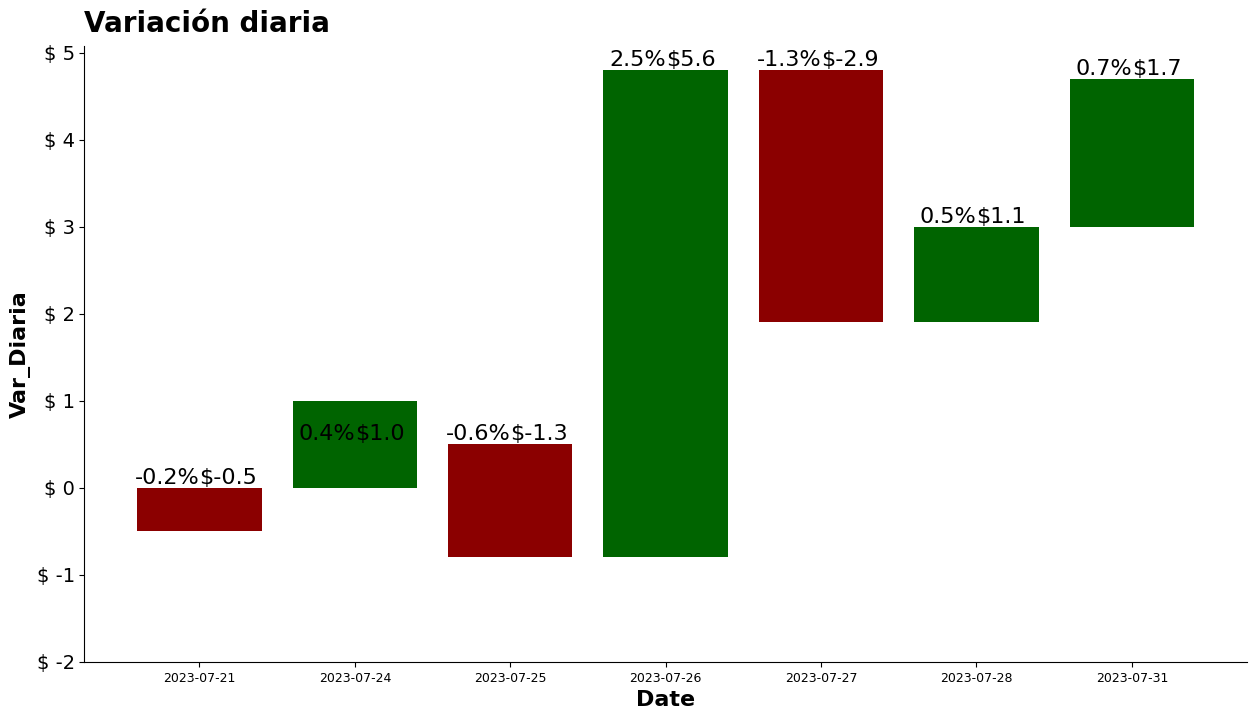

In [38]:
fig, ax = plt.subplots(figsize=(15,8))

plt.bar(x=VISA_1.index, height=VISA_1["Height"], bottom=VISA_1["Bottom"], color=VISA_1["Color"])

plt.xticks(VISA_1.index, VISA_1["Date"].dt.strftime('%Y-%m-%d'), fontdict=dict(fontsize=9))
plt.yticks(range(-2, 6, 1), ["$ {:,}".format(val) for val in range(-2, 6, 1)],fontdict=dict(fontsize=14))

for idx in range(len(VISA_1)):
    plt.text(x=VISA_1.index[idx], y=VISA_1["Cumulative"][idx],
             s="{:,}%".format(VISA_1["Var%_Diaria"][idx] if VISA_1["Var_Diaria"][idx]!=0 else VISA_1["Cumulative"][idx]),
             ha="right", va="bottom", fontdict=dict(fontsize=16))
    plt.text(x=VISA_1.index[idx], y=VISA_1["Cumulative"][idx],
             s="${:,}".format(VISA_1["Var_Diaria"][idx] if VISA_1["Var_Diaria"][idx]!=0 else VISA_1["Cumulative"][idx]),
             ha="left", va="bottom", fontdict=dict(fontsize=16))

plt.xlabel("Date", fontdict=dict(fontsize=16, fontweight="bold"))
plt.ylabel("Var_Diaria", fontdict=dict(fontsize=16, fontweight="bold"))
plt.title("Variación diaria", loc="left", pad=10, fontdict=dict(fontsize=20, fontweight="bold"))

ax.spines[[ "top", "right"]].set_visible(False)

plt.show()

**Interacción**

In [40]:
fig = go.Figure(go.Waterfall(
    name = "Var_diaria", orientation = "v",
    measure = ["relative", "relative", "relative", "relative", "relative", "relative", "relative", "total"],
    x = VISA_1['Date'].dt.strftime('%Y-%m-%d'),
    textposition = "outside",
    text = VISA_1["Var%_Diaria"],
    y = VISA_1['Var_Diaria'],
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
        title = "Variación diaria",
        showlegend = True
)

fig.update_layout(dict(xaxis = dict(type='date', tickformat="%Y-%m-%d",range = ['2023-07-20','2023-08-1'],nticks=20, tickfont=dict(size=10))))

fig.update_layout(template="plotly_white")

fig.show()

### **Gráfico de radar**

In [41]:
DATA=pd.read_csv("/root/.cache/kagglehub/datasets/paytonfisher/sp-500-companies-with-financial-information/versions/1/financials.csv")
DATA.head()

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.490,1.387211e+11,9.048000e+09,4.390271,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A.O. Smith Corp,Industrials,60.24,27.76,1.147959,1.70,68.39,48.925,1.078342e+10,6.010000e+08,3.575483,6.35,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.280,1.021210e+11,5.744000e+09,3.740480,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.050,1.813863e+11,1.031000e+10,6.291571,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture plc,Information Technology,150.51,25.47,1.714470,5.44,162.60,114.820,9.876586e+10,5.643228e+09,2.604117,10.62,http://www.sec.gov/cgi-bin/browse-edgar?action...


In [42]:
DATA_Sector=DATA.groupby(['Sector'])[['Price', '52 Week Low', '52 Week High']].agg(['mean']).reset_index()
DATA_Sector

,Sector,Price,52 Week Low,52 Week High
,,mean,mean,mean
0,Consumer Discretionary,124.034524,146.931427,96.092364
1,Consumer Staples,79.764118,92.832285,68.929441
2,Energy,57.887500,72.589687,48.141234
3,Financials,89.056029,101.821849,72.694468
4,Health Care,132.515738,160.758534,103.719253
5,Industrials,116.887612,134.579476,90.837024
6,Information Technology,119.242857,138.778641,91.891416
7,Materials,102.386800,118.038852,85.583248
8,Real Estate,88.712727,110.550455,82.878088


In [43]:
DATA_Sector.columns = ['Sector', 'Price', '52_W_L', '52_W_H']

In [44]:
DATA_Sector

,Sector,Price,52_W_L,52_W_H
0,Consumer Discretionary,124.034524,146.931427,96.092364
1,Consumer Staples,79.764118,92.832285,68.929441
2,Energy,57.887500,72.589687,48.141234
3,Financials,89.056029,101.821849,72.694468
4,Health Care,132.515738,160.758534,103.719253
5,Industrials,116.887612,134.579476,90.837024
6,Information Technology,119.242857,138.778641,91.891416
7,Materials,102.386800,118.038852,85.583248
8,Real Estate,88.712727,110.550455,82.878088
9,Telecommunication Services,33.603333,41.693333,29.503667


In [45]:
list(DATA_Sector)[1:]

['Price', '52_W_L', '52_W_H']

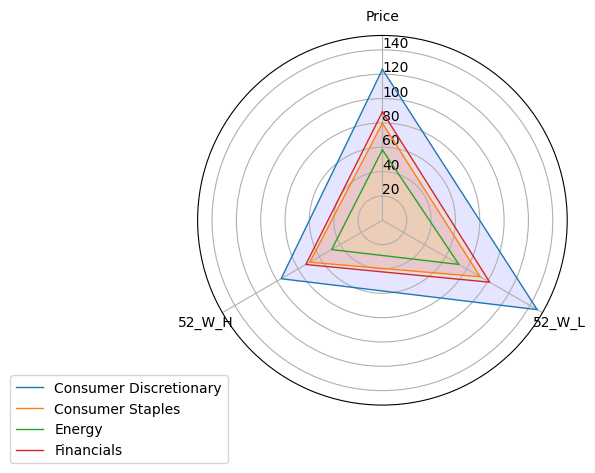

In [46]:
from math import pi

# number of variable
categories=list(DATA_Sector)[1:]
N = len(categories)

# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Initialise the spider plot
ax = plt.subplot(111, polar=True)

# If you want the first axis to be on top:
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories)

# Draw ylabels
ax.set_rlabel_position(0)
#plt.yticks([10,20,30], ["10","20","30"], color="grey", size=7)
#plt.ylim(0,40)


# ------- PART 2: Add plots

# Plot each individual = each line of the data
# I don't make a loop, because plotting more than 3 groups makes the chart unreadable

# Sector1
values=DATA_Sector.loc[0].drop('Sector').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="Consumer Discretionary")
ax.fill(angles, values, 'blue', alpha=0.1)

# Sector2
values=DATA_Sector.loc[1].drop('Sector').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="Consumer Staples")
ax.fill(angles, values, 'red', alpha=0.1)

# Sector3
values=DATA_Sector.loc[2].drop('Sector').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="Energy")
ax.fill(angles, values, 'yellow', alpha=0.1)

# Sector4
values=DATA_Sector.loc[3].drop('Sector').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="Financials")
ax.fill(angles, values, 'orange', alpha=0.1)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Show the graph
plt.show()

**Interacción**

In [47]:
#visualizamos de manera diferente
fig = px.line_polar(DATA_Sector, r='Price', theta='Sector', line_close=True)
fig.show()

In [48]:
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=DATA_Sector['Price'],
      theta=DATA_Sector['Sector'],
      fill='toself',
      name='Price'
))
fig.add_trace(go.Scatterpolar(
      r=DATA_Sector['52_W_L'],
      theta=DATA_Sector['Sector'],
      fill='toself',
      name='52_W_L'
))
fig.add_trace(go.Scatterpolar(
      r=DATA_Sector['52_W_H'],
      theta=DATA_Sector['Sector'],
      fill='toself',
      name='52_W_H'
))


### **Gráfico de puntos conectados**

In [11]:
import yfinance as yf

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_GOOG=Datos_GOOG.assign(SYMBOL_YAHOO_FINANCE='T_GOOG')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_AMZN = pd.DataFrame(yf.download('AMZN',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_AMZN=Datos_AMZN.assign(SYMBOL_YAHOO_FINANCE='T_AMZN')
Datos_AMZN.columns=Datos_AMZN.columns.droplevel(1)
Datos_MSFT = pd.DataFrame(yf.download('MSFT',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_MSFT=Datos_MSFT.assign(SYMBOL_YAHOO_FINANCE='T_MSFT')
Datos_MSFT.columns=Datos_MSFT.columns.droplevel(1)

Datos_JPM = pd.DataFrame(yf.download('JPM',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_JPM=Datos_JPM.assign(SYMBOL_YAHOO_FINANCE='B_JPM')
Datos_JPM.columns=Datos_JPM.columns.droplevel(1)
Datos_BAC = pd.DataFrame(yf.download('BAC',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_BAC=Datos_BAC.assign(SYMBOL_YAHOO_FINANCE='B_BAC')
Datos_BAC.columns=Datos_BAC.columns.droplevel(1)
Datos_HSBC = pd.DataFrame(yf.download('HSBC',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_HSBC=Datos_HSBC.assign(SYMBOL_YAHOO_FINANCE='B_HSBC')
Datos_HSBC.columns=Datos_HSBC.columns.droplevel(1)

Datos_EXXON = pd.DataFrame(yf.download('XOM',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_EXXON=Datos_EXXON.assign(SYMBOL_YAHOO_FINANCE='E_XOM')
Datos_EXXON.columns=Datos_EXXON.columns.droplevel(1)
Datos_CHEV = pd.DataFrame(yf.download('CVX',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_CHEV=Datos_CHEV.assign(SYMBOL_YAHOO_FINANCE='E_CVX')
Datos_CHEV.columns=Datos_CHEV.columns.droplevel(1)
Datos_SHEL = pd.DataFrame(yf.download('SHEL',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_SHEL=Datos_SHEL.assign(SYMBOL_YAHOO_FINANCE='E_SHEL')
Datos_SHEL.columns=Datos_SHEL.columns.droplevel(1)


#GENERACIÓN DE UN SOLO DATAFRAME
DATA_YAHOO_M=pd.concat([Datos_GOOG, Datos_AMZN, Datos_MSFT,Datos_JPM,Datos_BAC,Datos_HSBC,Datos_EXXON,Datos_CHEV,Datos_SHEL])
#RESETEO DE INDICE
DATA_YAHOO_M.reset_index(drop=True, inplace=True)
DATA_YAHOO_M

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,SYMBOL_YAHOO_FINANCE
0,2023-06-01,118.802361,T_GOOG
1,2023-07-01,131.724701,T_GOOG
2,2023-06-01,130.360001,T_AMZN
3,2023-07-01,133.679993,T_AMZN
4,2023-06-01,334.150116,T_MSFT
5,2023-07-01,329.616821,T_MSFT
6,2023-06-01,137.142578,B_JPM
7,2023-07-01,148.948318,B_JPM
8,2023-06-01,26.691000,B_BAC
9,2023-07-01,30.007931,B_BAC


In [12]:
DATA_YAHOO_M['Date'] = DATA_YAHOO_M['Date'].dt.strftime('%B')


In [13]:
df1 = DATA_YAHOO_M.pivot(index=['SYMBOL_YAHOO_FINANCE'], columns='Date', values='Close').reset_index()
df1.columns.name = ''
df1

,SYMBOL_YAHOO_FINANCE,July,June
0,B_BAC,30.007931,26.691000
1,B_HSBC,34.992596,33.183495
2,B_JPM,148.948318,137.142578
3,E_CVX,146.981308,141.314331
4,E_SHEL,55.666092,54.537056
5,E_XOM,98.318878,98.328072
6,T_AMZN,133.679993,130.360001
7,T_GOOG,131.724701,118.802361
8,T_MSFT,329.616821,334.150116


In [14]:
df1 = df1.set_index("SYMBOL_YAHOO_FINANCE").sort_values("July", ascending=True)
df1["change"] = df1["July"] / df1["June"] - 1

Con Matplotlib y Seaborn

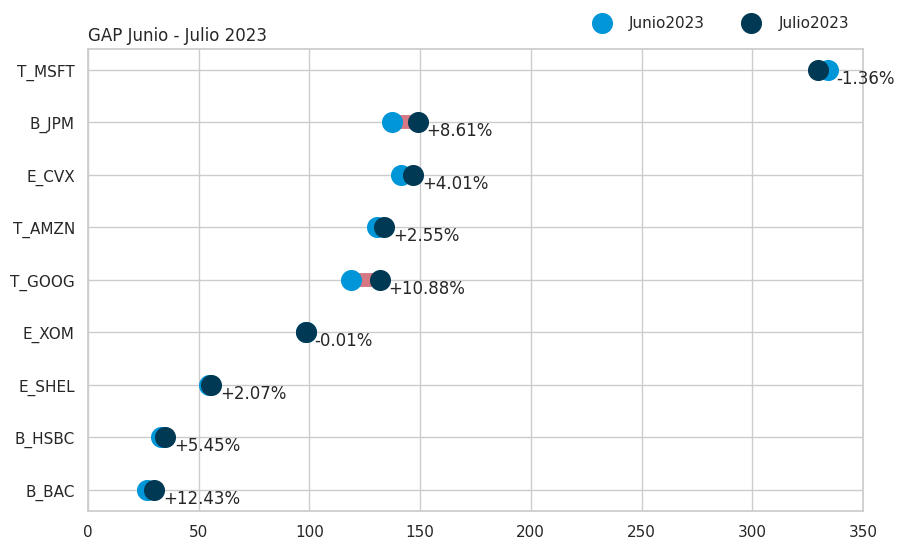

In [15]:
sns.set(style="whitegrid") #para tener grilla de fondo blanco

plt.figure(figsize=(10,6))
y_range = np.arange(1, len(df1.index) + 1)
colors = np.where(df1['June'] > df1['July'], '#d9d9d9', '#d57883')

plt.hlines(y=y_range, xmin=df1['June'], xmax=df1['July'],color=colors, lw=10)

plt.scatter(df1['June'], y_range, color='#0096d7', s=200, label='Junio2023', zorder=3)
plt.scatter(df1['July'], y_range, color='#003953', s=200 , label='Julio2023', zorder=3)

for (_, row), y in zip(df1.iterrows(), y_range):
    plt.annotate(f"{row['change']:+.2%}", (max(row["June"], row["July"]) + 4, y - 0.25))

plt.legend(ncol=2, bbox_to_anchor=(1., 1.01), loc="lower right", frameon=False)

plt.yticks(y_range, df1.index)
plt.title("GAP Junio - Julio 2023", loc='left')
plt.xlim(0, 350)

plt.grid(True)

plt.show()

In [16]:
df1

,July,June,change
SYMBOL_YAHOO_FINANCE,,,
B_BAC,30.007931,26.691000,0.124272
B_HSBC,34.992596,33.183495,0.054518
E_SHEL,55.666092,54.537056,0.020702
E_XOM,98.318878,98.328072,-0.000093
T_GOOG,131.724701,118.802361,0.108772
T_AMZN,133.679993,130.360001,0.025468
E_CVX,146.981308,141.314331,0.040102
B_JPM,148.948318,137.142578,0.086084
T_MSFT,329.616821,334.150116,-0.013567


Interacción

In [17]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=df1['June'], y=df1.index, mode='markers', name='June', marker_color='#0096d7', marker_symbol='circle-dot', marker_size=15))
fig.add_trace(go.Scatter(x=df1['July'], y=df1.index, mode='markers', name='July', marker_color='#003953', marker_symbol='circle-dot', marker_size=15))

#calculo diferencia para barra
diff = [h - l for h, l in zip(df1['July'], df1['June'])]
#barra
fig.add_trace(go.Bar(x=diff, y=df1.index, base=df1['June'], width=0.3, marker_color='#d57883', showlegend=False, orientation='h'))

fig.add_traces(go.Scatter(x=df1['July'], y=df1.index, mode="text", name='Variación',textposition="top right", text =round(df1['change']*100,2)))

fig.update_layout(yaxis={'type': 'category','showgrid': True}, font=dict(size=15))

fig.update_layout(go.Layout(
  margin=go.layout.Margin(
        l=100, #left margin
        r=0, #right margin
        b=100, #bottom margin
        t=20  #top margin
    )))

fig.update_layout(dict(xaxis=dict(tickmode="array",tickvals=np.arange(0, 360,20).astype(int))))

fig.update_layout(template='none')

fig.show()

In [39]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=df1['June'], y=df1.index, mode='markers', name='June', marker_color='#0096d7', marker_symbol='circle-dot', marker_size=15))
fig.add_trace(go.Scatter(x=df1['July'], y=df1.index, mode='markers', name='July', marker_color='#003953', marker_symbol='circle-dot', marker_size=15))

#calculo diferencia para barra
diff = [h - l for h, l in zip(df1['July'], df1['June'])]
#barra
fig.add_trace(go.Bar(x=diff, y=df1.index, base=df1['June'], width=0.3, marker_color='#d57883', showlegend=False, orientation='h'))

fig.update_layout(yaxis={'type': 'category','showgrid': True}, font=dict(size=15))

fig.update_layout(go.Layout(
  margin=go.layout.Margin(l=155,r=0, b=50, t=50)))

fig.update_layout(template="plotly_white")

fig.update_layout(dict(xaxis=dict(tickmode="array",tickvals=np.arange(0, 360,20).astype(int))))

fig.add_annotation(x=30, y=0.3,text="▲ 12.43%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=35, y=1.3,text="▲ 5.5%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=55, y=2.3,text="▲ 2.0%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=100, y=3.3,text="▼ -0.01%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=125, y=4.3,text="▲ 10.9%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=130, y=5.3,text="▲ 2.6%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=145, y=6.3,text="▲ 4.0%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=143, y=7.3,text="▲ 8.6%",showarrow=False,font=dict(color="black", size=12))
fig.add_annotation(x=330, y=8.3,text="▼ -1.4%",showarrow=False,font=dict(color="black", size=12))


fig.show()

### **Gráfico de coordenadas paralelas**

In [56]:
import yfinance as yf

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_GOOG=Datos_GOOG.assign(SYMBOL_YAHOO_FINANCE='T_GOOG')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_AMZN = pd.DataFrame(yf.download('AMZN',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_AMZN=Datos_AMZN.assign(SYMBOL_YAHOO_FINANCE='T_AMZN')
Datos_AMZN.columns=Datos_AMZN.columns.droplevel(1)
Datos_MSFT = pd.DataFrame(yf.download('MSFT',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_MSFT=Datos_MSFT.assign(SYMBOL_YAHOO_FINANCE='T_MSFT')
Datos_MSFT.columns=Datos_MSFT.columns.droplevel(1)

Datos_JPM = pd.DataFrame(yf.download('JPM',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_JPM=Datos_JPM.assign(SYMBOL_YAHOO_FINANCE='B_JPM')
Datos_JPM.columns=Datos_JPM.columns.droplevel(1)
Datos_BAC = pd.DataFrame(yf.download('BAC',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_BAC=Datos_BAC.assign(SYMBOL_YAHOO_FINANCE='B_BAC')
Datos_BAC.columns=Datos_BAC.columns.droplevel(1)
Datos_HSBC = pd.DataFrame(yf.download('HSBC',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_HSBC=Datos_HSBC.assign(SYMBOL_YAHOO_FINANCE='B_HSBC')
Datos_HSBC.columns=Datos_HSBC.columns.droplevel(1)

Datos_EXXON = pd.DataFrame(yf.download('XOM',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_EXXON=Datos_EXXON.assign(SYMBOL_YAHOO_FINANCE='E_XOM')
Datos_EXXON.columns=Datos_EXXON.columns.droplevel(1)
Datos_CHEV = pd.DataFrame(yf.download('CVX',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_CHEV=Datos_CHEV.assign(SYMBOL_YAHOO_FINANCE='E_CVX')
Datos_CHEV.columns=Datos_CHEV.columns.droplevel(1)
Datos_SHEL = pd.DataFrame(yf.download('SHEL',  start='2023-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_SHEL=Datos_SHEL.assign(SYMBOL_YAHOO_FINANCE='E_SHEL')
Datos_SHEL.columns=Datos_SHEL.columns.droplevel(1)


#GENERACIÓN DE UN SOLO DATAFRAME
DATA_YAHOO_M=pd.concat([Datos_GOOG, Datos_AMZN, Datos_MSFT,Datos_JPM,Datos_BAC,Datos_HSBC,Datos_EXXON,Datos_CHEV,Datos_SHEL])
#RESETEO DE INDICE
DATA_YAHOO_M.reset_index(drop=True, inplace=True)
DATA_YAHOO_M

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,SYMBOL_YAHOO_FINANCE
0,2023-06-01,118.802361,T_GOOG
1,2023-07-01,131.724716,T_GOOG
2,2023-06-01,130.360001,T_AMZN
3,2023-07-01,133.679993,T_AMZN
4,2023-06-01,334.150055,T_MSFT
5,2023-07-01,329.616791,T_MSFT
6,2023-06-01,137.142563,B_JPM
7,2023-07-01,148.948303,B_JPM
8,2023-06-01,26.691002,B_BAC
9,2023-07-01,30.007933,B_BAC


In [57]:
DATA_YAHOO_M['Date'] = DATA_YAHOO_M['Date'].dt.strftime('%B')


In [58]:
DATA_YAHOO_M

Price,Date,Close,SYMBOL_YAHOO_FINANCE
0,June,118.802361,T_GOOG
1,July,131.724716,T_GOOG
2,June,130.360001,T_AMZN
3,July,133.679993,T_AMZN
4,June,334.150055,T_MSFT
5,July,329.616791,T_MSFT
6,June,137.142563,B_JPM
7,July,148.948303,B_JPM
8,June,26.691002,B_BAC
9,July,30.007933,B_BAC


In [59]:
activos= DATA_YAHOO_M['SYMBOL_YAHOO_FINANCE'].unique()
activos

array(['T_GOOG', 'T_AMZN', 'T_MSFT', 'B_JPM', 'B_BAC', 'B_HSBC', 'E_XOM',
       'E_CVX', 'E_SHEL'], dtype=object)

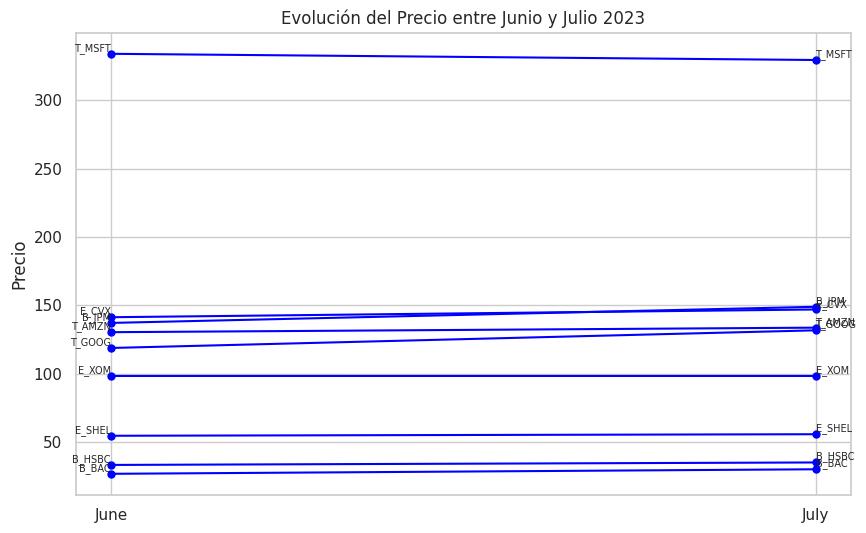

In [60]:
activos= DATA_YAHOO_M['SYMBOL_YAHOO_FINANCE'].unique()

fig, ax = plt.subplots(figsize=(10,6))
for i in activos:
    temp = DATA_YAHOO_M[DATA_YAHOO_M['SYMBOL_YAHOO_FINANCE'] == i]
    plt.plot(temp.Date, temp.Close, color='blue', marker='o', markersize=5)
    plt.text(temp.Date.values[0], temp.Close.values[0], i, ha='right', va='bottom', fontsize=7)
    plt.text(temp.Date.values[1], temp.Close.values[1], i, ha='left', va='bottom', fontsize=7)

ticks = plt.xticks(['June', 'July'])
ax.set_title('Evolución del Precio entre Junio y Julio 2023')
ax.set_ylabel('Precio')
plt.show()

Interacción

In [61]:
df1 = DATA_YAHOO_M.pivot(index=['SYMBOL_YAHOO_FINANCE'], columns='Date', values='Close').reset_index()
df1.columns.name = ''
df1

,SYMBOL_YAHOO_FINANCE,July,June
0,B_BAC,30.007933,26.691002
1,B_HSBC,34.992596,33.183502
2,B_JPM,148.948303,137.142563
3,E_CVX,146.981277,141.314346
4,E_SHEL,55.666092,54.537060
5,E_XOM,98.318878,98.328056
6,T_AMZN,133.679993,130.360001
7,T_GOOG,131.724716,118.802361
8,T_MSFT,329.616791,334.150055


In [62]:
from ctypes import alignment
fig = go.Figure(data=go.Parcoords(line = dict(color = df1.index,colorscale = 'agsunset'),
                            dimensions = list([dict(range = [0,360],label = 'June', values = df1['June'], ticktext = df1['SYMBOL_YAHOO_FINANCE'], tickvals = df1['June']),
                                               dict(range = [0,360],label = 'July', values = df1['July']),
                                            ])
                                    )
               )


fig.update_layout(plot_bgcolor = 'white',paper_bgcolor = 'white')

fig.update_layout( title={'text': "Evolución del Precio entre Junio y Julio 2023",'y':0.9,'x':0.5,'xanchor': 'center','yanchor': 'top'})

fig.show()

### **Botones**

In [40]:
import yfinance as yf

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2023-06-1', end='2023-08-01')).reset_index()
Datos_GOOG=Datos_GOOG.assign(SYMBOL_YAHOO_FINANCE='T_GOOG', SECTOR='TECNOLOGIA')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_GOOG

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,SYMBOL_YAHOO_FINANCE,SECTOR
0,2023-06-01,122.792221,123.486969,121.700472,121.898969,30772700,T_GOOG,TECNOLOGIA
1,2023-06-02,123.735100,125.204005,122.831928,123.060199,26980100,T_GOOG,TECNOLOGIA
2,2023-06-05,125.065041,126.474390,122.911308,123.080039,32305500,T_GOOG,TECNOLOGIA
3,2023-06-06,126.355293,127.327940,124.419919,125.065047,26638300,T_GOOG,TECNOLOGIA
4,2023-06-07,121.581367,128.072317,121.204220,126.017848,52539000,T_GOOG,TECNOLOGIA
5,2023-06-08,121.224060,122.305890,120.330808,121.313389,29389200,T_GOOG,TECNOLOGIA
6,2023-06-09,121.313400,122.831926,120.995800,121.333247,23778300,T_GOOG,TECNOLOGIA
7,2023-06-12,122.712822,123.119751,120.747674,121.869198,28306400,T_GOOG,TECNOLOGIA
8,2023-06-13,122.901390,124.221418,122.256263,124.042768,22278300,T_GOOG,TECNOLOGIA
9,2023-06-14,122.742577,123.119732,120.539224,122.176851,30592300,T_GOOG,TECNOLOGIA


In [43]:
#Botón desplegable con las diferentes variables

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=Datos_GOOG['Date'],
               y=Datos_GOOG['Close'],
               name="Close",
               line=dict(color="black")))

fig.add_trace(
    go.Scatter(x=Datos_GOOG['Date'],
               y=Datos_GOOG['Open'],
               name="Open Price",
               visible=False,
               line=dict(color="yellow")))

fig.add_trace(
    go.Scatter(x=Datos_GOOG['Date'],
               y=Datos_GOOG['High'],
               name="High Price",
               visible=False,
               line=dict(color="green", dash="dash")))

fig.add_trace(
    go.Scatter(x=Datos_GOOG['Date'],
               y=Datos_GOOG['Low'],
               name="Low Price",
               visible=False,
               line=dict(color="red", dash="dash")))

# Add Buttons

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=list([
                dict(label="Close",
                     method="update",
                     args=[{"visible": [True, False, False, False]},
                           {"title": "Cotización de cierre ajustado Google Junio-Julio 2023"}]),
                dict(label="Open",
                     method="update",
                     args=[{"visible": [False, True, False, False]},
                           {"title": "Cotización apertura Google Junio-Julio 2023"}]),
                dict(label="High",
                     method="update",
                     args=[{"visible": [False, False, True, False]},
                           {"title": "Cotización máxima Google Junio-Julio 2023"}]),
                dict(label="Low",
                     method="update",
                     args=[{"visible": [False, False, False, True]},
                           {"title": "Cotización mínima Google Junio-Julio 2023"}]),
                dict(label="All",
                     method="update",
                     args=[{"visible": [True, True, True, True]},
                           {"title": "Cotización Google Junio-Julio 2023"}]),
            ]),
        )
    ])

# Set title
fig.update_layout(title_text="Cotización Google Junio-Julio 2023")

fig.update_layout(plot_bgcolor = 'white',paper_bgcolor = 'white')

fig.update_layout(dict(xaxis = dict( type='date', tickformat="%Y-%m-%d",range = ['2023-06-01','2023-08-1'],nticks=120,tickfont=dict(size=8),tickangle=45)))

fig.show()

In [44]:
import yfinance as yf

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_GOOG=Datos_GOOG.assign(SYMBOL_YAHOO_FINANCE='T_GOOG', SECTOR='TECNOLOGIA')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_AMZN = pd.DataFrame(yf.download('AMZN',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_AMZN=Datos_AMZN.assign(SYMBOL_YAHOO_FINANCE='T_AMZN', SECTOR='TECNOLOGIA')
Datos_AMZN.columns=Datos_AMZN.columns.droplevel(1)
Datos_MSFT = pd.DataFrame(yf.download('MSFT',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_MSFT=Datos_MSFT.assign(SYMBOL_YAHOO_FINANCE='T_MSFT', SECTOR='TECNOLOGIA')
Datos_MSFT.columns=Datos_MSFT.columns.droplevel(1)

Datos_JPM = pd.DataFrame(yf.download('JPM',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_JPM=Datos_JPM.assign(SYMBOL_YAHOO_FINANCE='B_JPM', SECTOR='BANCARIO')
Datos_JPM.columns=Datos_JPM.columns.droplevel(1)
Datos_BAC = pd.DataFrame(yf.download('BAC',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_BAC=Datos_BAC.assign(SYMBOL_YAHOO_FINANCE='B_BAC', SECTOR='BANCARIO')
Datos_BAC.columns=Datos_BAC.columns.droplevel(1)
Datos_HSBC = pd.DataFrame(yf.download('HSBC',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_HSBC=Datos_HSBC.assign(SYMBOL_YAHOO_FINANCE='B_HSBC', SECTOR='BANCARIO')
Datos_HSBC.columns=Datos_HSBC.columns.droplevel(1)

Datos_EXXON = pd.DataFrame(yf.download('XOM',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_EXXON=Datos_EXXON.assign(SYMBOL_YAHOO_FINANCE='E_XOM', SECTOR='ENERGIA')
Datos_EXXON.columns=Datos_EXXON.columns.droplevel(1)
Datos_CHEV = pd.DataFrame(yf.download('CVX',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_CHEV=Datos_CHEV.assign(SYMBOL_YAHOO_FINANCE='E_CVX', SECTOR='ENERGIA')
Datos_CHEV.columns=Datos_CHEV.columns.droplevel(1)
Datos_SHEL = pd.DataFrame(yf.download('SHEL',  start='2022-06-1', end='2023-08-01', interval='1mo')[['Close']]).reset_index()
Datos_SHEL=Datos_SHEL.assign(SYMBOL_YAHOO_FINANCE='E_SHEL', SECTOR='ENERGIA')
Datos_SHEL.columns=Datos_SHEL.columns.droplevel(1)

#GENERACIÓN DE UN SOLO DATAFRAME
DATA_YAHOO_M=pd.concat([Datos_GOOG,Datos_AMZN, Datos_MSFT,Datos_JPM,Datos_BAC,Datos_HSBC,Datos_EXXON,Datos_CHEV,Datos_SHEL])
#RESETEO DE INDICE
DATA_YAHOO_M.reset_index(drop=True, inplace=True)
DATA_YAHOO_M

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,SYMBOL_YAHOO_FINANCE,SECTOR
0,2022-06-01,108.145874,T_GOOG,TECNOLOGIA
1,2022-07-01,115.447716,T_GOOG,TECNOLOGIA
2,2022-08-01,107.408455,T_GOOG,TECNOLOGIA
3,2022-09-01,94.932709,T_GOOG,TECNOLOGIA
4,2022-10-01,93.801270,T_GOOG,TECNOLOGIA
...,...,...,...,...
121,2023-03-01,51.480289,E_SHEL,ENERGIA
122,2023-04-01,55.452702,E_SHEL,ENERGIA
123,2023-05-01,50.102474,E_SHEL,ENERGIA
124,2023-06-01,54.537060,E_SHEL,ENERGIA


In [45]:
#Se puede crear un botón para mostrar diferentes medidas para varios activos
import plotly.io as pio

aggs = ["avg","median","mode","stddev","min","max","first","last"]

agg = []
agg_func = []
for i in range(0, len(aggs)):
    agg = dict(
        args=['transforms[0].aggregations[0].func', aggs[i]],
        label=aggs[i],
        method='restyle'
    )
    agg_func.append(agg)

data = [dict(
        type = 'scatter',
        x = DATA_YAHOO_M['SYMBOL_YAHOO_FINANCE'],
        y = DATA_YAHOO_M['Close'],
        mode = 'markers',
        marker = dict(color = 'red', size=15),
        transforms = [dict(type = 'aggregate',groups = DATA_YAHOO_M['SYMBOL_YAHOO_FINANCE'],aggregations = [dict(target = 'y', func = 'avg', enabled = True)])]
      )]

layout = dict(
  title = '<b>Medidas agregadas de Precio de Cierre Ajustado Junio 2022 - Julio 2023</b><br>Use el menú desplegable para cambiar la agregación',
  xaxis = dict(title = 'Activo'),
  yaxis = dict(title = 'Close', range = [0,360]),
  updatemenus = [dict(
        x = 0.85,
        y = 1.1,
        xref = 'paper',
        yref = 'paper',
        yanchor = 'top',
        active = 1,
        showactive = False,
        buttons = agg_func
  )]
)

fig_dict = dict(data=data, layout=layout)

pio.show(fig_dict, validate=False)

### **Filtro**

In [46]:
import yfinance as yf

DATA_YAHOO = pd.DataFrame(yf.download(['GOOGL','AMZN','MSFT','JPM','BAC','HSBC','XOM','CVX','SHEL'], start='2023-06-1', end='2023-08-01')[['Close']]).reset_index()
DATA_YAHOO.columns=['FECHA','GOOG_AC','AMZN_AC','MSFT_AC','JPM_AC','BAC_AC','HSBC_AC','XOM_AC','CVX_AC','SHEL_AC']
DATA_YAHOO['FECHA']=DATA_YAHOO['FECHA'].dt.strftime('%Y-%m-%d')
DATA_YAHOO = DATA_YAHOO.set_index('FECHA')
DATA_YAHOO

[*********************100%***********************]  9 of 9 completed


,GOOG_AC,AMZN_AC,MSFT_AC,JPM_AC,BAC_AC,HSBC_AC,XOM_AC,CVX_AC,SHEL_AC
FECHA,,,,,,,,,
2023-06-01,122.769997,26.050634,136.653290,122.792221,31.340906,129.730988,326.339447,51.565422,94.761650
2023-06-02,124.250000,26.922741,140.335419,123.735100,31.675920,132.456116,329.106567,52.622204,96.962006
2023-06-05,125.300003,26.763327,139.661865,125.065041,31.600536,131.154831,329.636383,52.125427,96.531105
2023-06-06,126.610001,27.410368,139.913330,126.355293,31.994186,131.390579,327.418823,52.116398,97.319557
2023-06-07,121.230003,27.644806,143.541580,121.581367,32.144947,132.663559,317.312012,52.568020,99.501564
2023-06-08,124.250000,27.410368,143.011703,121.224060,32.203571,132.701279,319.156769,53.146088,99.189865
2023-06-09,123.430000,27.447878,142.670471,121.313400,32.203571,132.965317,320.658112,52.775757,98.456390
2023-06-12,126.570000,27.316595,141.296387,122.712822,31.902056,132.955902,325.623199,52.224792,97.567093
2023-06-13,126.660004,27.569788,142.356110,122.901390,32.211948,133.917694,328.017334,52.739620,97.585442


In [47]:
DATA_YAHOO.columns

Index(['GOOG_AC', 'AMZN_AC', 'MSFT_AC', 'JPM_AC', 'BAC_AC', 'HSBC_AC',
       'XOM_AC', 'CVX_AC', 'SHEL_AC'],
      dtype='object')

In [48]:
#Botón filtro por activo

fig = go.Figure()

fig.add_trace(go.Scatter(x=DATA_YAHOO.index,
                         y=DATA_YAHOO[DATA_YAHOO.columns[0]],
                         visible=True)
             )

fig.update_layout(dict(title = '<b>Precio de Cierre Junio 2022 - Julio 2023</b><br>Use el menú desplegable para cambiar de activo',
                       xaxis = dict(type='date', tickformat="%Y-%m-%d",range = ['2023-06-01','2023-08-1'],nticks=62,tickfont=dict(size=8),tickangle=45)))

fig.update_layout(margin=dict(l=50, r=100, t=100, b=100))
fig.update_layout(template='none')

updatemenu = []
buttons = []

# creación del filtro como botón
for col in DATA_YAHOO.columns:
    buttons.append(dict(method='restyle',
                        label=col,
                        visible=True,
                        args=[{'y':[DATA_YAHOO[col]],
                               'x':[DATA_YAHOO.index],
                               'type':'scatter'}, [0]],
                        )
                  )

# ajustes del botón
updatemenu = []
your_menu = dict()
updatemenu.append(your_menu)

updatemenu[0]['buttons'] = buttons
updatemenu[0]['direction'] = 'down'
updatemenu[0]['showactive'] = True

# se agrega el botón a la figura
fig.update_layout(showlegend=False, updatemenus=updatemenu)
fig.show()

In [49]:
import yfinance as yf
import pandas as pd

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_GOOG=Datos_GOOG.assign(ACTIVO='GOOG', SECTOR='TECNOLOGIA')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_AMZN = pd.DataFrame(yf.download('AMZN',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_AMZN=Datos_AMZN.assign(ACTIVO='AMZN', SECTOR='TECNOLOGIA')
Datos_AMZN.columns=Datos_AMZN.columns.droplevel(1)
Datos_MSFT = pd.DataFrame(yf.download('MSFT',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_MSFT=Datos_MSFT.assign(ACTIVO='MSFT', SECTOR='TECNOLOGIA')
Datos_MSFT.columns=Datos_MSFT.columns.droplevel(1)

Datos_JPM = pd.DataFrame(yf.download('JPM',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_JPM=Datos_JPM.assign(ACTIVO='JPM', SECTOR='BANCARIO')
Datos_JPM.columns=Datos_JPM.columns.droplevel(1)
Datos_BAC = pd.DataFrame(yf.download('BAC',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_BAC=Datos_BAC.assign(ACTIVO='BAC', SECTOR='BANCARIO')
Datos_BAC.columns=Datos_BAC.columns.droplevel(1)
Datos_HSBC = pd.DataFrame(yf.download('HSBC',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_HSBC=Datos_HSBC.assign(ACTIVO='HSBC', SECTOR='BANCARIO')
Datos_HSBC.columns=Datos_HSBC.columns.droplevel(1)

Datos_EXXON = pd.DataFrame(yf.download('XOM',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_EXXON=Datos_EXXON.assign(ACTIVO='XOM', SECTOR='ENERGIA')
Datos_EXXON.columns=Datos_EXXON.columns.droplevel(1)
Datos_CHEV = pd.DataFrame(yf.download('CVX',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_CHEV=Datos_CHEV.assign(ACTIVO='CVX', SECTOR='ENERGIA')
Datos_CHEV.columns=Datos_CHEV.columns.droplevel(1)
Datos_SHEL = pd.DataFrame(yf.download('SHEL',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_SHEL=Datos_SHEL.assign(ACTIVO='SHEL', SECTOR='ENERGIA')
Datos_SHEL.columns=Datos_SHEL.columns.droplevel(1)


#GENERACIÓN DE UN SOLO DATAFRAME
DATA_YAHOO_M=pd.concat([Datos_GOOG,Datos_AMZN, Datos_MSFT,Datos_JPM,Datos_BAC,Datos_HSBC,Datos_EXXON,Datos_CHEV,Datos_SHEL])
#RESETEO DE INDICE
DATA_YAHOO_M.reset_index(drop=True, inplace=True)
DATA_YAHOO_M['Date']=DATA_YAHOO_M['Date'].dt.strftime('%Y-%m-%d')
DATA_YAHOO_M=round(DATA_YAHOO_M,2)
DATA_YAHOO_M

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,ACTIVO,SECTOR
0,2022-06-01,108.15,118.45,104.26,113.99,770754000,GOOG,TECNOLOGIA
1,2022-07-01,115.45,118.79,103.29,107.12,789529700,GOOG,TECNOLOGIA
2,2022-08-01,107.41,121.51,106.99,114.44,515852700,GOOG,TECNOLOGIA
3,2022-09-01,94.93,110.78,94.84,107.47,613278900,GOOG,TECNOLOGIA
4,2022-10-01,93.80,104.03,91.11,96.03,681488300,GOOG,TECNOLOGIA
...,...,...,...,...,...,...,...,...
121,2023-03-01,51.48,56.12,46.94,55.02,132932243,SHEL,ENERGIA
122,2023-04-01,55.45,55.75,52.80,54.35,78205258,SHEL,ENERGIA
123,2023-05-01,50.10,55.50,49.90,54.99,94999731,SHEL,ENERGIA
124,2023-06-01,54.54,55.25,50.61,50.74,103863077,SHEL,ENERGIA


In [50]:
# Tabla de datos usando un botón filtro por activo

fig = go.Figure(go.Table(header={"values": DATA_YAHOO_M.columns}, cells={"values": DATA_YAHOO_M.T.values}))
fig.update_layout(
    updatemenus=[
        {
            "buttons": [
                {
                    "label": c,
                    "method": "update",
                    "args": [
                        {
                            "cells": {
                                "values": DATA_YAHOO_M.T.values
                                if c == "All"
                                else DATA_YAHOO_M.loc[DATA_YAHOO_M["ACTIVO"].eq(c)].T.values
                            }
                        }
                    ],
                }
                for c in ["All"] + DATA_YAHOO_M["ACTIVO"].unique().tolist()
            ]
        }
    ]
)

fig.update_layout(margin=dict(l=50, r=100, t=100, b=100),
                  title = '<b>Cotización de activos Junio 2022 - Julio 2023</b><br>Use el menú desplegable para filtrar un activo')
fig.update_layout(template='none')

In [51]:
#aplicar formato en la tabla y agregando otro botón filtro para el período

fig = go.Figure(go.Table(header={'line_color':'darkslategray','fill_color':'paleturquoise',"values": DATA_YAHOO_M.columns},
                         cells={'fill_color':'lavender',"values": DATA_YAHOO_M.T.values}))
fig.update_layout(
    updatemenus=[
        {
            "y": 1 - (i / 5),
            "buttons": [
                {
                    "label": c,
                    "method": "restyle",
                    "args": [
                        {
                            "cells": {
                                "values": DATA_YAHOO_M.T.values
                                if c == "All"
                                else DATA_YAHOO_M.loc[DATA_YAHOO_M[menu].eq(c)].T.values
                            }
                        }
                    ],
                }
                for c in ["All"] + DATA_YAHOO_M[menu].unique().tolist()
            ],
        }
        for i, menu in enumerate(["ACTIVO", "Date"])
    ]
)

fig.update_layout(margin=dict(l=50, r=100, t=100, b=100),
                  title = '<b>Cotización de activos Junio 2022 - Julio 2023</b><br>Use el menú desplegable para filtrar un activo')
fig.update_layout(template='none')

### **Controles deslizantes**

In [52]:
import yfinance as yf

Datos_GOOG = pd.DataFrame(yf.download('GOOGL', start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_GOOG=Datos_GOOG.assign(ACTIVO='GOOG', SECTOR='TECNOLOGIA')
Datos_GOOG.columns=Datos_GOOG.columns.droplevel(1)
Datos_AMZN = pd.DataFrame(yf.download('AMZN',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_AMZN=Datos_AMZN.assign(ACTIVO='AMZN', SECTOR='TECNOLOGIA')
Datos_AMZN.columns=Datos_AMZN.columns.droplevel(1)
Datos_MSFT = pd.DataFrame(yf.download('MSFT',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_MSFT=Datos_MSFT.assign(ACTIVO='MSFT', SECTOR='TECNOLOGIA')
Datos_MSFT.columns=Datos_MSFT.columns.droplevel(1)

Datos_JPM = pd.DataFrame(yf.download('JPM',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_JPM=Datos_JPM.assign(ACTIVO='JPM', SECTOR='BANCARIO')
Datos_JPM.columns=Datos_JPM.columns.droplevel(1)
Datos_BAC = pd.DataFrame(yf.download('BAC',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_BAC=Datos_BAC.assign(ACTIVO='BAC', SECTOR='BANCARIO')
Datos_BAC.columns=Datos_BAC.columns.droplevel(1)
Datos_HSBC = pd.DataFrame(yf.download('HSBC',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_HSBC=Datos_HSBC.assign(ACTIVO='HSBC', SECTOR='BANCARIO')
Datos_HSBC.columns=Datos_HSBC.columns.droplevel(1)

Datos_EXXON = pd.DataFrame(yf.download('XOM',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_EXXON=Datos_EXXON.assign(ACTIVO='XOM', SECTOR='ENERGIA')
Datos_EXXON.columns=Datos_EXXON.columns.droplevel(1)
Datos_CHEV = pd.DataFrame(yf.download('CVX',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_CHEV=Datos_CHEV.assign(ACTIVO='CVX', SECTOR='ENERGIA')
Datos_CHEV.columns=Datos_CHEV.columns.droplevel(1)
Datos_SHEL = pd.DataFrame(yf.download('SHEL',  start='2022-06-1', end='2023-08-01', interval='1mo')).reset_index()
Datos_SHEL=Datos_SHEL.assign(ACTIVO='SHEL', SECTOR='ENERGIA')
Datos_SHEL.columns=Datos_SHEL.columns.droplevel(1)


#GENERACIÓN DE UN SOLO DATAFRAME
DATA_YAHOO_M=pd.concat([Datos_GOOG,Datos_AMZN, Datos_MSFT,Datos_JPM,Datos_BAC,Datos_HSBC,Datos_EXXON,Datos_CHEV,Datos_SHEL])
#RESETEO DE INDICE
DATA_YAHOO_M.reset_index(drop=True, inplace=True)
DATA_YAHOO_M['Date']=DATA_YAHOO_M['Date'].dt.strftime('%Y-%m')
DATA_YAHOO_M=DATA_YAHOO_M.rename(columns={'Date':'Año-Mes'})
DATA_YAHOO_M=round(DATA_YAHOO_M,2)
DATA_YAHOO_M

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Año-Mes,Close,High,Low,Open,Volume,ACTIVO,SECTOR
0,2022-06,108.15,118.45,104.26,113.99,770754000,GOOG,TECNOLOGIA
1,2022-07,115.45,118.79,103.29,107.12,789529700,GOOG,TECNOLOGIA
2,2022-08,107.41,121.51,106.99,114.44,515852700,GOOG,TECNOLOGIA
3,2022-09,94.93,110.78,94.84,107.47,613278900,GOOG,TECNOLOGIA
4,2022-10,93.80,104.03,91.11,96.03,681488300,GOOG,TECNOLOGIA
...,...,...,...,...,...,...,...,...
121,2023-03,51.48,56.12,46.94,55.02,132932243,SHEL,ENERGIA
122,2023-04,55.45,55.75,52.80,54.35,78205258,SHEL,ENERGIA
123,2023-05,50.10,55.50,49.90,54.99,94999731,SHEL,ENERGIA
124,2023-06,54.54,55.25,50.61,50.74,103863077,SHEL,ENERGIA


In [54]:
fig = px.scatter(DATA_YAHOO_M, x="Año-Mes", y="Close", animation_frame="Año-Mes", animation_group="SECTOR",
           size="Volume", color="ACTIVO", hover_name="SECTOR",
           log_x=False, size_max=50,  range_y=[0,360])

fig.update_layout(dict(xaxis = dict( type='date', tickformat="%Y-%m-%d",range = ['2022-05','2023-08'],nticks=20,tickfont=dict(size=8),tickangle=0),
                       title = '<b>Evolutivo de Cotización de activos</b>'))

fig.show()